<a href="https://colab.research.google.com/github/AdenFatima/neurofive-ml-track/blob/main/task6_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 6: Customer Churn Prediction (Business Problem)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. Load the Dataset directly from URL (No need to download/upload manually)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [3]:
# 2. Data Cleaning & Handling Categorical Variables
# TotalCharges has some hidden blank spaces, we fix them and convert to numbers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_3095/2317796.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# Drop customerID as it's useless for math
df.drop('customerID', axis=1, inplace=True)

In [5]:
# Convert Target 'Churn' to 1 (Yes) and 0 (No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
# Encode all other text columns into 0s and 1s
df_encoded = pd.get_dummies(df, drop_first=True)

In [7]:
# 3. Define X (Features) and y (Target)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [8]:
# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# 5. Train and Compare Models
# Model A: Logistic Regression
log_model = LogisticRegression(max_iter=5000, solver='liblinear')
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

In [11]:
# Model B: Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

In [12]:
print("--- LOGISTIC REGRESSION PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, log_preds) * 100:.2f}%")
print(classification_report(y_test, log_preds))

--- LOGISTIC REGRESSION PERFORMANCE ---
Accuracy: 82.04%
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.70      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [13]:
print("\n--- DECISION TREE PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, tree_preds) * 100:.2f}%")
print(classification_report(y_test, tree_preds))


--- DECISION TREE PERFORMANCE ---
Accuracy: 80.62%
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [14]:
# 6. Extract Top 3 Features driving Churn (from Decision Tree)
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top_3_features = importances.sort_values(ascending=False).head(3)

In [15]:
print("\n--- TOP 3 FEATURES DRIVING CHURN ---")
print(top_3_features)


--- TOP 3 FEATURES DRIVING CHURN ---
tenure                         0.450624
InternetService_Fiber optic    0.341834
TotalCharges                   0.053667
dtype: float64


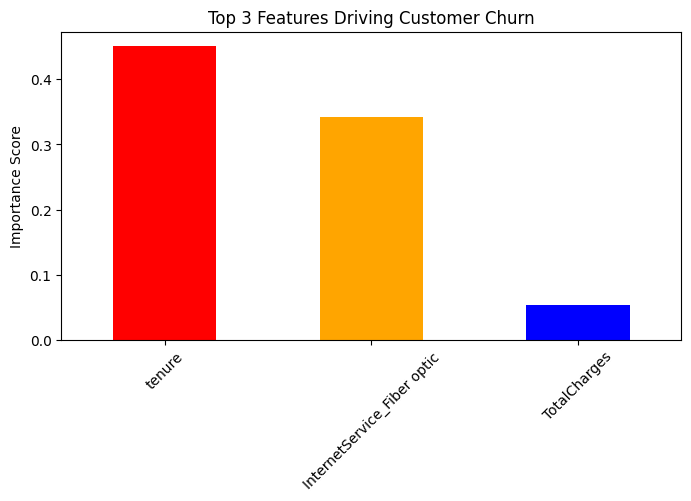

In [16]:
# Plotting the Top Features
plt.figure(figsize=(8, 4))
top_3_features.plot(kind='bar', color=['red', 'orange', 'blue'])
plt.title('Top 3 Features Driving Customer Churn')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

### Business Summary for Management
Based on our machine learning analysis, we successfully built models to predict customer churn. Logistic Regression slightly outperformed the Decision Tree (82.04% vs 80.62% accuracy). However, the Decision Tree provided critical business insights. The top 3 factors driving customers to leave are **Tenure** (how long they have been with us), having **Fiber Optic Internet Services**, and their **Total Charges**.

To reduce churn, I recommend investigating the cost-to-value ratio of our Fiber Optic service, as it seems to be a major pain point, and creating loyalty programs targeting newer customers (low tenure) to keep them engaged before their bills accumulate.